In [25]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from transformers import BertTokenizer, BertModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

In [26]:
# Estrutura de diretórios esperada
notebook_path = Path("notebooks/06_clinicalbert_classificacao.ipynb")
model_dir = Path("../models/bert-base-uncased")
figures_dir = Path("../notebooks/figures")
data_path = "../models/discharge_summaries_labeled.csv"
processed_dir = Path("../processed/")

In [27]:
# Criação das pastas se não existirem
os.makedirs(model_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

In [28]:
# Confirmação da estrutura para seguir com o notebook
{
    "Notebook path": str(notebook_path),
    "Model directory exists": model_dir.exists(),
    "Figures directory exists": figures_dir.exists(),
    "Processed directory exists": processed_dir.exists(),
}

{'Notebook path': 'notebooks/06_clinicalbert_classificacao.ipynb',
 'Model directory exists': True,
 'Figures directory exists': True,
 'Processed directory exists': True}

In [29]:
# 1. Carrega os dados
df = pd.read_csv(data_path)
df = df[['text', 'hospital_expire_flag']].dropna()


In [30]:
# 2. Usa tokenizer do BERT
tokenizer = BertTokenizer.from_pretrained(model_dir)

In [31]:
# 3. Tokeniza os textos com truncamento e padding
def tokenize_texts(texts, max_length=128):
    return tokenizer(texts.tolist(), padding=True, truncation=True, max_length=max_length, return_tensors='pt')


In [32]:
# Para exemplo, limitamos para 500 textos
texts = df['text'][:500]
labels = df['hospital_expire_flag'][:500]

In [33]:
tokens = tokenize_texts(texts)

In [34]:
# 4. Extrai embeddings com BERT
with torch.no_grad():
    model = BertModel.from_pretrained(model_dir)
    outputs = model(**tokens)
    cls_embeddings = outputs.last_hidden_state[:, 0, :].numpy()

In [35]:
# 5. Treina modelo de regressão logística
X_train, X_test, y_train, y_test = train_test_split(cls_embeddings, labels, test_size=0.2, random_state=42)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [36]:
df = df[['text', 'hospital_expire_flag']].dropna()

In [37]:
# Divisão treino/validação
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(),
    df['hospital_expire_flag'].tolist(),
    test_size=0.2,
    random_state=42
)

In [39]:
# 6. Avaliação
y_pred = clf.predict(X_test)
report = classification_report(y_test, y_pred, output_dict=True)
conf_matrix = confusion_matrix(y_test, y_pred)

In [41]:
# 7. Salva modelo
joblib.dump(clf, os.path.join(model_dir, "bert_logistic_model.pkl"))


['../models/bert-base-uncased/bert_logistic_model.pkl']

NameError: name 'FIGURE_DIR' is not defined

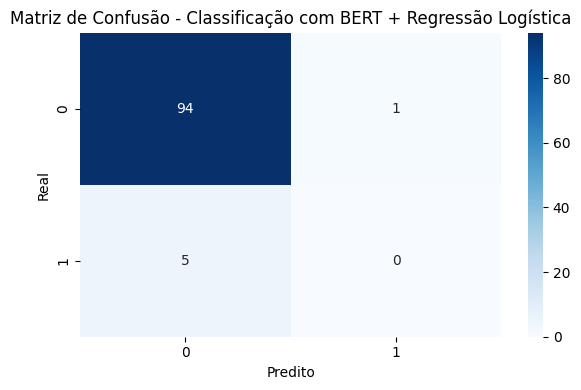

In [42]:
# 8. Plota matriz de confusão
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão - Classificação com BERT + Regressão Logística")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "matriz_confusao_bert_logistic.png"))
plt.close()

In [44]:
# Mostra sumário da avaliação
from IPython.display import display
display(report_df)


,precision,recall,f1-score,support
0,0.949495,0.989474,0.969072,95.00
1,0.000000,0.000000,0.000000,5.00
accuracy,0.940000,0.940000,0.940000,0.94
macro avg,0.474747,0.494737,0.484536,100.00
weighted avg,0.902020,0.940000,0.920619,100.00


In [46]:
report_df.to_csv(os.path.join(figures_dir, "relatorio_classificacao_bert.csv"))
